In [1]:
print("ML LAB 4     Ex 5      Classification Algorithm")
import pandas as pd

ML LAB 4     Ex 5      Classification Algorithm


In [2]:
df = pd.read_csv("C:\\Pratheeksha SJU\\6th Semester\\Machine Learning\\onlinefraud.csv")
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [5]:
corr_df = df.corr(numeric_only = True)
corr_df

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
isFlaggedFraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [10]:
df.columns = (df.columns.str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)
df_new = df.drop(['step','nameOrig','nameDest','newbalanceOrig','oldbalanceDest'],axis=1)


In [12]:
#Defining targets
x= df_new.drop('isFraud',axis=1)
y= df_new['isFraud']

In [14]:
#importing necessary library
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
x['type'] = le.fit_transform(x['type'])

In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42)


In [16]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='gini',max_depth=5,random_state=42)
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [22]:
y_pred = model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Classification Report: ",classification_report(y_test,y_pred))
print("Confusion Matrix: ",confusion_matrix(y_test,y_pred))

Accuracy:  0.9993241777758219
Classification Report:                precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906351
           1       0.76      0.69      0.72      2435

    accuracy                           1.00   1908786
   macro avg       0.88      0.84      0.86   1908786
weighted avg       1.00      1.00      1.00   1908786

Confusion Matrix:  [[1905822     529]
 [    761    1674]]


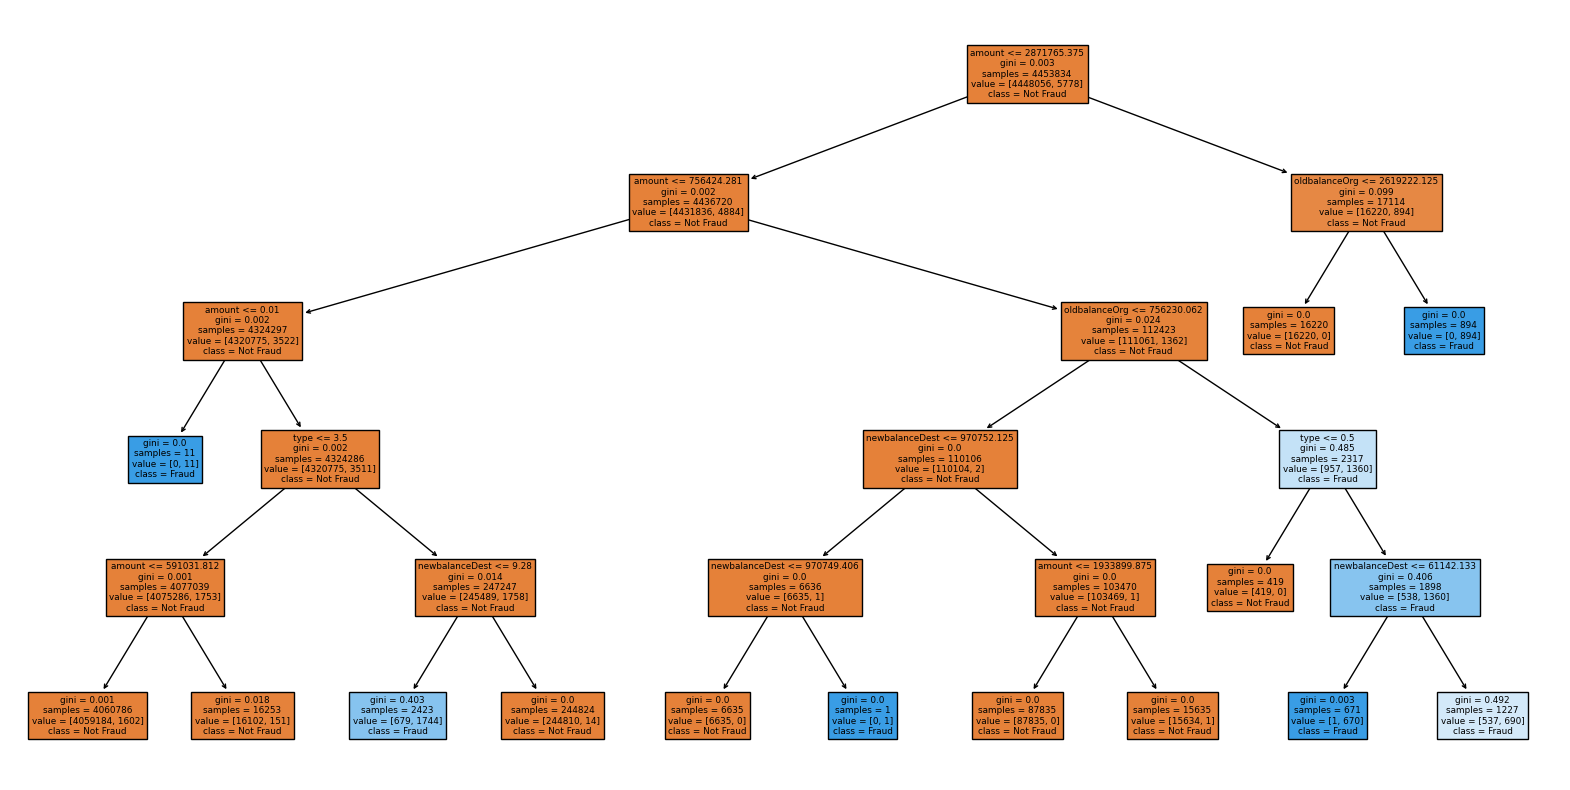

In [30]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=['Not Fraud', 'Fraud'],
    filled=True
)
plt.show()


In [39]:
model2 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
model2.fit(x_train,y_train)
y_pred2 = model2.predict(x_test)
y_pred2

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [43]:
print("Accuracy: ",accuracy_score(y_test,y_pred2))
print("Classification Report: ",classification_report(y_test,y_pred2))
print("Confusion Matrix: \n",confusion_matrix(y_test,y_pred2))

Accuracy:  0.9391896210470948
Classification Report:                precision    recall  f1-score   support

           0       1.00      0.94      0.97   1906351
           1       0.02      0.99      0.04      2435

    accuracy                           0.94   1908786
   macro avg       0.51      0.96      0.50   1908786
weighted avg       1.00      0.94      0.97   1908786

Confusion Matrix: 
 [[1790301  116050]
 [     24    2411]]


Before balancing the dataset, the Decision Tree model showed high accuracy but poor performance in detecting fraudulent transactions due to class imbalance. Most fraud cases were misclassified as non-fraud, making the model unreliable for fraud detection. After applying class balancing, the model demonstrated improved recall and F1-score for the fraud class, indicating better detection of fraudulent transactions. Although overall accuracy slightly decreased, the balanced model produced more meaningful and reliable results and is therefore considered the better model.
The balanced Decision Tree model performs better as it prioritizes fraud detection over misleading accuracy.